In [1]:
# Load the required libraries
import os
from typing import List
import random
import pickle
import tqdm
import gseapy as gp
from matplotlib.patches import Patch
from pathlib import Path
import pooch
import zipfile
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import anndata as ad
import seaborn as sns
from matplotlib import style
import matplotlib as mpl
import matplotlib.patches as mpatches
import datetime
import torch
from sklearn.metrics.pairwise import cosine_similarity
from perturbgen.configs import ROOT
from sklearn.metrics import balanced_accuracy_score

from perturbgen.src.metric import (
    compute_distribution_distances,
    compute_emd,
    evaluate_emd,
    evaluate_mmd,
    lin_reg_summary,
)

from adjustText import adjust_text
from scipy.stats import spearmanr, pearsonr, chi2_contingency

from tqdm import tqdm
import hashlib

Set seed below and define base directory

In [2]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [3]:
np.random.seed(42)
random.seed(42)

In [4]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [5]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [6]:
res_dir = 'T_perturb/res/hspc/etv6/'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

In [7]:
print(ROOT)

/lustre/scratch126/cellgen/lotfollahi/kl11


### 1. Data Preprocessing

In [8]:
adata_etv6 = sc.read_h5ad('T_perturb/res/hspc/etv6/adata_etv6_processed.h5ad')

In [9]:
adata_pert = sc.read_h5ad(f'{ROOT}/T_perturb/res/hspc/perturbation_5k/20250719-05:43_minference_adata_gETV6_ssrc_tmask.h5ad')

In [10]:
adata_pert.layers['true_counts'][:10, :10]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 2., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [11]:
# find overlapping genes
overlap_genes = adata_etv6.var_names.intersection(adata_pert.var_names)
print(f'Number of overlapping genes: {len(overlap_genes)}')
# filter ETV to same genes as in perturbed data
adata_etv6 = adata_etv6[:, overlap_genes].copy()
adata_pert = adata_pert[:, overlap_genes].copy()

Number of overlapping genes: 4890


In [12]:
# log normalize both datasets
sc.pp.normalize_total(adata_etv6, target_sum=1e4)
sc.pp.log1p(adata_etv6)
adata_pred = adata_pert.copy()
adata_pred.X = adata_pred.layers['pred_counts']
adata_pred.obs['perturb_mode'] = 'pred'
adata_pert.obs['perturb_mode'] = 'perturb'

adata_all = ad.concat([adata_pred, adata_pert], join='outer')
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


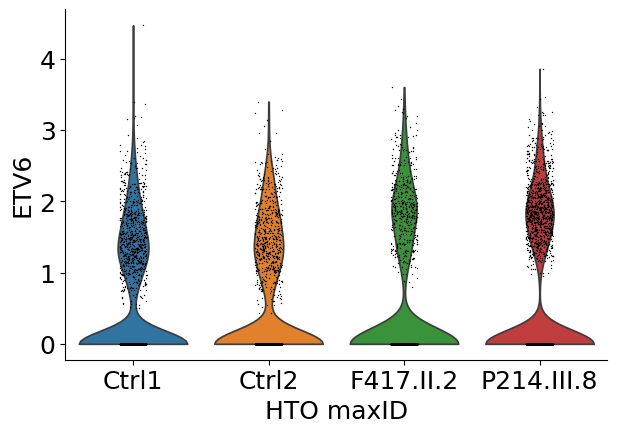

In [62]:
# check on-target effect on ETV6 GEX
sc.pl.violin(
    adata_etv6,
    keys=['ETV6'],
    groupby='HTO_maxID',
)


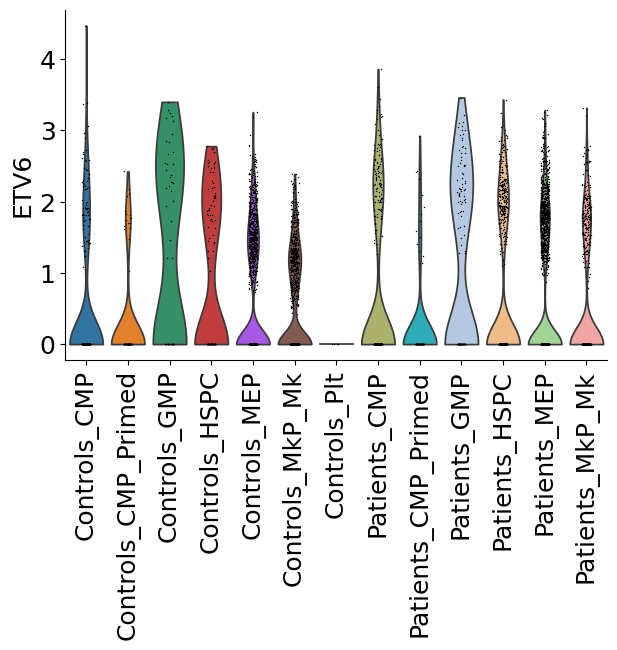

In [13]:
sc.pl.violin(
    adata_etv6,
    keys=['ETV6'],
    groupby='celltypes_ETV6status',
    rotation=90,
)


In [14]:
adata_etv6

AnnData object with n_obs × n_vars = 7715 × 4890
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'MULTI_ID', 'MULTI_classification', 'barcode', 'assignment', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'souporcell_classif', 'HT0_souporcell_classif', 'HT0_souporcell_classif_final', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'individuals', 'ETV6status', 'sample', 'RNA_snn_res.1.5', 'RNA_snn_res.3', 'RNA_snn_res.4', 'celltypes', 'nCount_AUC', 'nFeature_AUC', 'nCount_BIN', 'nFeature_BIN', 'celltypes_ETV6status', 'delta_logprob', 'soupor_cluster_from_hs', 'pt_ctrl_label', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells'
    uns: 'ETV6status_colors', 'HTO_classification.global_colors', 'HTO_

In [15]:

# Regress out library size & mito %, then scale
# sc.pp.regress_out(adata_etv6, ['nCount_RNA'])
# sc.pp.scale(adata_etv6, max_value=10)

# --- 2) PCA and quick visual checks ---
sc.tl.pca(adata_etv6, svd_solver='arpack')


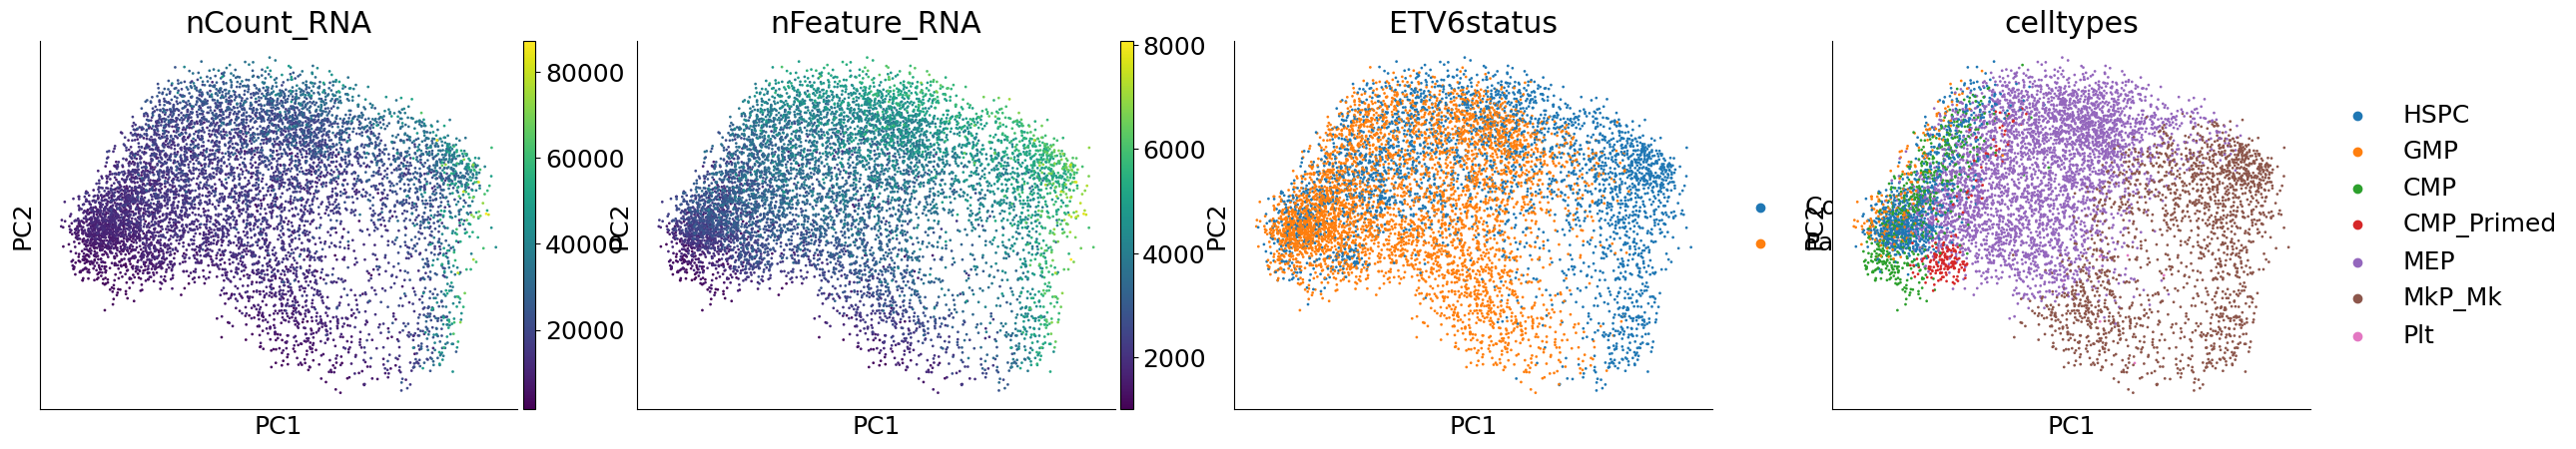

|r| vs nCount_RNA (first 10 PCs):
 PC1     0.623
PC2     0.396
PC3     0.077
PC4     0.198
PC5     0.190
PC6     0.130
PC7     0.218
PC8     0.089
PC9     0.079
PC10    0.001
dtype: float64
|r| vs nFeature_RNA (first 10 PCs):
 PC1     0.683
PC2     0.503
PC3     0.021
PC4     0.164
PC5     0.199
PC6     0.137
PC7     0.289
PC8     0.122
PC9     0.065
PC10    0.026
dtype: float64


In [16]:
# explore read depth effect
sc.pl.pca(adata_etv6, color=['nCount_RNA', 'nFeature_RNA', 'ETV6status', 'celltypes'])

# --- 3) Quantify correlation of PCs with QC metrics ---
pcs = pd.DataFrame(adata_etv6.obsm['X_pca'], index=adata_etv6.obs_names,
                   columns=[f'PC{i+1}' for i in range(adata_etv6.obsm['X_pca'].shape[1])])
qc = adata_etv6.obs[['nCount_RNA', 'nFeature_RNA',]].copy()

def corr_to_qc(pcs_df, qc_series, top_k=10, label='total_counts'):
    r = pcs_df.iloc[:, :top_k].apply(lambda pc: pc.corr(qc_series))
    print(f'|r| vs {label} (first {top_k} PCs):\n', r.abs().round(3))
    return r

r_counts  = corr_to_qc(pcs, qc['nCount_RNA'],      top_k=10, label='nCount_RNA')
r_genes   = corr_to_qc(pcs, qc['nFeature_RNA'], top_k=10, label='nFeature_RNA')

In [17]:
celltypes = [
    'LT-HSC', 'ST-HSC', 'MPP',
    'LMPP', 'PreProB', 'Small_Pre_B', 'Immature_B', 'Pro_B', 'Cycling_Pro_B', 'Large_Pre_B', 'pDC', 
    'MEMP', 'MK', 'Early_Ery', 'Late_Ery', 'BaEoMa',
    'GMP', 'DC_pre', 'Mono_pre', 'Macrophage'
]


In [19]:
adata_all.obs

,sex,phase,tissue,celltype_v2,diff_state,cell_idx,perturb_mode
0,M,G1,ABM_29-50y,MK,terminal,19618,pred
1,M,S,ABM_29-50y,MK,terminal,19626,pred
2,M,G1,ABM_29-50y,MK,terminal,19872,pred
3,M,G2M,ABM_29-50y,MK,terminal,20184,pred
4,M,S,ABM_29-50y,MK,terminal,20310,pred
...,...,...,...,...,...,...,...
28009,F,G1,YS,Macrophage,terminal,44634,perturb
28010,F,G1,YS,Macrophage,terminal,44635,perturb
28011,F,G1,YS,Macrophage,terminal,44636,perturb
28012,F,S,YS,Macrophage,terminal,44637,perturb


In [20]:
adata_all.obs['celltype_v2'] = adata_all.obs['celltype_v2'].astype('category')
adata_all.obs['perturb_mode'] = adata_all.obs['perturb_mode'].astype('category')
deg_results = {}
for celltype in adata_all.obs['celltype_v2'].unique():
    
    # Subset AnnData to just this celltype
    adata_celltype = adata_all[adata_all.obs['celltype_v2'] == celltype].copy()
    # check if celltype has enough cells
    if adata_celltype.shape[0] > 3:
        # Perform DGE for perturb_mode within this celltype
        sc.tl.rank_genes_groups(
            adata_celltype, 
            groupby='perturb_mode', 
            groups=['perturb'],
            reference='pred',
            method='wilcoxon',
        )
        # set DEG filter to p-value < 0.05 and logfoldchange > 0.5 and <-0.5 
        deg_df = sc.get.rank_genes_groups_df(adata_celltype, group='perturb', key='rank_genes_groups')
        deg_df_sig = deg_df[(deg_df['pvals_adj'] < 0.05) & ((deg_df['logfoldchanges'] > 0.5) | (deg_df['logfoldchanges'] < -0.5))]
        n_sig_degs = deg_df_sig.shape[0]
        deg_results[celltype] = n_sig_degs

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packag

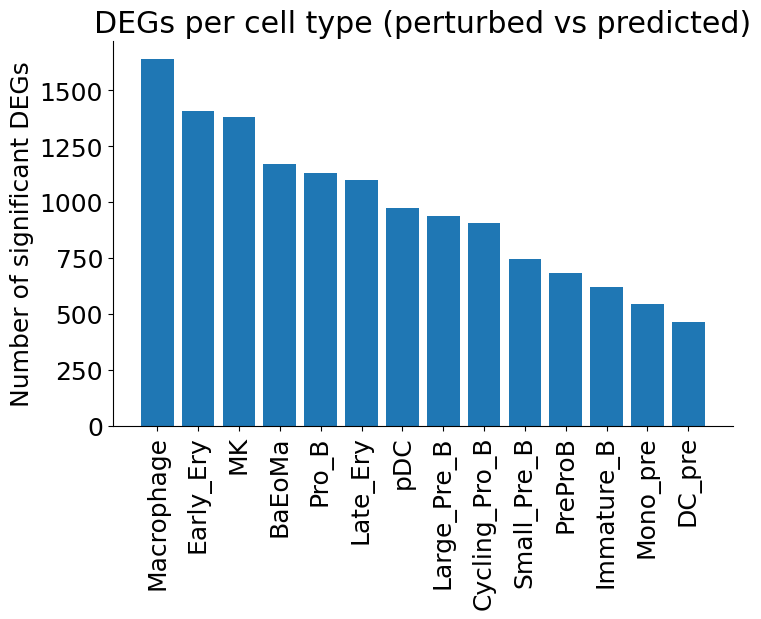

In [21]:
# make dataframe
n_degs = pd.DataFrame(index = deg_results.keys(), data = deg_results.values(), columns = ['n_sig_DEGs'])
n_degs = n_degs.sort_values("n_sig_DEGs", ascending=False)
n_degs['celltype'] = n_degs.index

# plot
plt.figure(figsize=(8,5))
plt.bar(n_degs["celltype"], n_degs["n_sig_DEGs"])
plt.xticks(rotation=90)
plt.ylabel("Number of significant DEGs")
plt.title("DEGs per cell type (perturbed vs predicted)")
plt.show()

### 2. Compare logFC to ETV6 monogeneic disease

In [22]:
adata_pert_megK = adata_all[adata_all.obs['celltype_v2'].isin(['MK'])].copy()

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
adata_etv6.obs['celltypes']

D6_AAACCTGCATACGCCG        MEP
D6_AAAGATGAGTAGGCCA        MEP
D6_AAATGCCCATGGGACA        MEP
D6_AACCGCGGTTTGACTG        MEP
D6_AACGTTGGTTCAGTAC        CMP
                         ...  
D11_TTTGGTTGTATGGTTC    MkP_Mk
D11_TTTGTCACAGCGATCC    MkP_Mk
D11_TTTGTCACATCGGGTC    MkP_Mk
D11_TTTGTCAGTAAGGATT    MkP_Mk
D11_TTTGTCAGTTCGGGCT    MkP_Mk
Name: celltypes, Length: 7715, dtype: category
Categories (7, object): ['HSPC', 'GMP', 'CMP', 'CMP_Primed', 'MEP', 'MkP_Mk', 'Plt']

In [24]:
adata_etv6_megK = adata_etv6[adata_etv6.obs['celltypes'].isin(['MkP_Mk'])].copy()
adata_etv6_memp_megK = adata_etv6[adata_etv6.obs['celltypes'].isin(['MEP', 'MkP_Mk'])].copy()

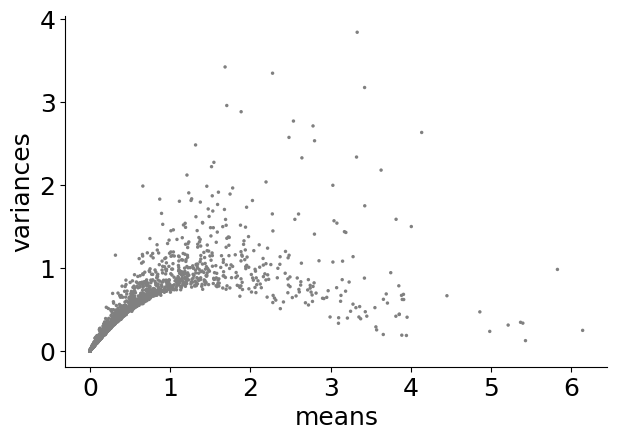

In [25]:
# use scanpy to plot gene mean variance relationship
adata_etv6_megK.var['means'] = adata_etv6_megK.X.mean(axis=0).A1
adata_etv6_megK.var['variances'] = np.var(adata_etv6_megK.X.toarray(), axis=0)
sc.pl.scatter(adata_etv6_megK, x='means', y='variances')

In [26]:
adata_etv6_megK

AnnData object with n_obs × n_vars = 1842 × 4890
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'MULTI_ID', 'MULTI_classification', 'barcode', 'assignment', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'souporcell_classif', 'HT0_souporcell_classif', 'HT0_souporcell_classif_final', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'individuals', 'ETV6status', 'sample', 'RNA_snn_res.1.5', 'RNA_snn_res.3', 'RNA_snn_res.4', 'celltypes', 'nCount_AUC', 'nFeature_AUC', 'nCount_BIN', 'nFeature_BIN', 'celltypes_ETV6status', 'delta_logprob', 'soupor_cluster_from_hs', 'pt_ctrl_label', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells', 'means', 'variances'
    uns: 'ETV6status_colors', 'HTO_classification

In [27]:
adata_etv6_megK.obs['celltypes_ETV6status']

D6_CCTACACCAGTTAACC     Controls_MkP_Mk
D6_GGTGCGTAGGCATGTG     Controls_MkP_Mk
D6_TGCCCTACACCGGAAA     Controls_MkP_Mk
D6_AGTGGGAGTCCGAATT     Patients_MkP_Mk
D6_CACACCTTCTTGGGTA     Patients_MkP_Mk
                             ...       
D11_TTTGGTTGTATGGTTC    Patients_MkP_Mk
D11_TTTGTCACAGCGATCC    Patients_MkP_Mk
D11_TTTGTCACATCGGGTC    Patients_MkP_Mk
D11_TTTGTCAGTAAGGATT    Patients_MkP_Mk
D11_TTTGTCAGTTCGGGCT    Controls_MkP_Mk
Name: celltypes_ETV6status, Length: 1842, dtype: category
Categories (2, object): ['Controls_MkP_Mk', 'Patients_MkP_Mk']

In [28]:
# subset adata_etv6_megK to only genes in adata_pert_megK
adata_etv6_megK = adata_etv6_megK[:, adata_etv6_megK.var_names.isin(adata_pert_megK.var_names)].copy()
adata_etv6_memp_megK = adata_etv6_memp_megK[:, adata_etv6_memp_megK.var_names.isin(adata_pert_megK.var_names)].copy()

In [29]:
adata_etv6_megK

AnnData object with n_obs × n_vars = 1842 × 4890
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'MULTI_ID', 'MULTI_classification', 'barcode', 'assignment', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'souporcell_classif', 'HT0_souporcell_classif', 'HT0_souporcell_classif_final', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'individuals', 'ETV6status', 'sample', 'RNA_snn_res.1.5', 'RNA_snn_res.3', 'RNA_snn_res.4', 'celltypes', 'nCount_AUC', 'nFeature_AUC', 'nCount_BIN', 'nFeature_BIN', 'celltypes_ETV6status', 'delta_logprob', 'soupor_cluster_from_hs', 'pt_ctrl_label', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells', 'means', 'variances'
    uns: 'ETV6status_colors', 'HTO_classification

In [30]:
adata_etv6_megK.obs['ETV6status'].value_counts()

ETV6status
Controls    1104
Patients     738
Name: count, dtype: int64

In [31]:
adata_etv6_memp_megK.obs['ETV6status'].value_counts()

ETV6status
Patients    3135
Controls    2735
Name: count, dtype: int64

In [32]:
# Perform DEG (e.g., using Wilcoxon test)
sc.tl.rank_genes_groups(
    adata_etv6_megK,
    groupby="ETV6status",
    method="wilcoxon",
    reference="Controls",  # Patient vs Control
)

# Convert results to dataframe
degs_etv6 = sc.get.rank_genes_groups_df(adata_etv6_megK, group="Patients")
# significant DEGs (padj < 0.05 and logfoldchange > 0.5 or <-0.5)
degs_etv6_sig = degs_etv6[(degs_etv6['pvals_adj'] < 0.05) & ((degs_etv6['logfoldchanges'] > 0.5) | (degs_etv6['logfoldchanges'] < -0.5))]


In [33]:
# Perform DEG (e.g., using Wilcoxon test)
sc.tl.rank_genes_groups(
    adata_etv6_memp_megK,
    groupby="ETV6status",
    method="wilcoxon",
    reference="Controls",  # Patient vs Control
)

# Convert results to dataframe
degs_memp_megk_etv6 = sc.get.rank_genes_groups_df(adata_etv6_memp_megK, group="Patients")
# significant DEGs (padj < 0.05 and logfoldchange > 1.0 or <-1.0)
degs_memp_megk_etv6_sig = degs_memp_megk_etv6[(degs_memp_megk_etv6['pvals_adj'] < 0.05) & ((degs_memp_megk_etv6['logfoldchanges'] > 1.0) | (degs_memp_megk_etv6['logfoldchanges'] < -1.0))]

In [34]:
adata_pert_megK.obs.perturb_mode.value_counts()

perturb_mode
perturb    1180
pred       1180
Name: count, dtype: int64

In [35]:
sc.tl.rank_genes_groups(
    adata_pert_megK,
    groupby="perturb_mode",
    method="wilcoxon",
    reference="pred",  # Patient vs Control
)
degs_pert = sc.get.rank_genes_groups_df(adata_pert_megK, group="perturb")
# # significant DEGs (padj < 0.05 and logfoldchange > 0.5 or <-0.5)
degs_pert_sig = degs_pert[(degs_pert['pvals_adj'] < 0.05) & ((degs_pert['logfoldchanges'] > 0.5) | (degs_pert['logfoldchanges'] < -0.5))]

In [36]:
degs_pert_sig

,names,scores,logfoldchanges,pvals,pvals_adj
0,LYZ,24.242102,2.557118,8.010520e-130,2.797960e-127
1,S100A9,22.649172,4.219895,1.421600e-113,2.780650e-111
2,SAMHD1,21.154329,3.031480,2.517469e-99,3.730432e-97
3,NAMPT,20.375431,1.474534,2.762778e-92,3.295118e-90
4,LCP1,20.306131,1.527818,1.134995e-91,1.321459e-89
...,...,...,...,...,...
4885,PRKAR2B,-26.796177,-2.357968,3.580250e-158,3.501484e-155
4886,MPIG6B,-27.473093,-2.354235,3.681826e-166,4.501033e-163
4887,ITGA2B,-27.627398,-3.048981,5.216557e-168,8.502987e-165
4888,RAP1B,-28.384666,-1.764272,3.126844e-177,7.645133e-174


In [37]:
# check intersection of upregulated and downregulated genes
up_etv6 = set(degs_memp_megk_etv6_sig[degs_memp_megk_etv6_sig['logfoldchanges'] > 0]['names'])
down_etv6 = set(degs_memp_megk_etv6_sig[degs_memp_megk_etv6_sig['logfoldchanges'] < 0]['names'])
up_pert = set(degs_pert_sig[degs_pert_sig['logfoldchanges'] > 0]['names'])
down_pert = set(degs_pert_sig[degs_pert_sig['logfoldchanges'] < 0]['names'])
# now find intersection
print(f'Number of upregulated genes in ETV6 vs Control: {len(up_etv6)}')
print(f'Number of upregulated genes in Perturb vs Pred: {len(up_pert)}')
print(f'Number of overlapping upregulated genes: {len(up_etv6.intersection(up_pert))}')
print(f'Number of downregulated genes in ETV6 vs Control: {len(down_etv6)}')
print(f'Number of downregulated genes in Perturb vs Pred: {len(down_pert)}')
print(f'Number of overlapping downregulated genes: {len(down_etv6.intersection(down_pert))}')

Number of upregulated genes in ETV6 vs Control: 156
Number of upregulated genes in Perturb vs Pred: 876
Number of overlapping upregulated genes: 66
Number of downregulated genes in ETV6 vs Control: 372
Number of downregulated genes in Perturb vs Pred: 504
Number of overlapping downregulated genes: 124


In [38]:
# check intersection of upregulated and downregulated genes
up_etv6 = set(degs_etv6_sig[degs_etv6_sig['logfoldchanges'] > 0]['names'])
down_etv6 = set(degs_etv6_sig[degs_etv6_sig['logfoldchanges'] < 0]['names'])
up_pert = set(degs_pert_sig[degs_pert_sig['logfoldchanges'] > 0]['names'])
down_pert = set(degs_pert_sig[degs_pert_sig['logfoldchanges'] < 0]['names'])
# now find intersection
print(f'Number of upregulated genes in ETV6 vs Control: {len(up_etv6)}')
print(f'Number of upregulated genes in Perturb vs Pred: {len(up_pert)}')
print(f'Number of overlapping upregulated genes: {len(up_etv6.intersection(up_pert))}')
print(f'Number of downregulated genes in ETV6 vs Control: {len(down_etv6)}')
print(f'Number of downregulated genes in Perturb vs Pred: {len(down_pert)}')
print(f'Number of overlapping downregulated genes: {len(down_etv6.intersection(down_pert))}')

Number of upregulated genes in ETV6 vs Control: 215
Number of upregulated genes in Perturb vs Pred: 876
Number of overlapping upregulated genes: 79
Number of downregulated genes in ETV6 vs Control: 1182
Number of downregulated genes in Perturb vs Pred: 504
Number of overlapping downregulated genes: 239


In [40]:
# perform GSEA on the ranked genes
go_bio = gp.get_library(name='GO_Biological_Process_2025', organism='Human')
reactome_2024 = gp.get_library(name='Reactome_Pathways_2024', organism='Human')
msigdb = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

In [41]:
# extract ranking statistics for genes in degs_filtered_df
etv6_ranks = pd.DataFrame({
    'gene': degs_etv6['names'],
    'scores': degs_etv6['scores'],
})
etv6_ranks.index = etv6_ranks['gene']
etv6_ranks.drop(columns=['gene'], inplace=True)
etv6_ranks.index.name = None
# sorting by scores
etv6_ranks = etv6_ranks.sort_values('scores', ascending=False)

In [42]:
# extract ranking statistics for genes in degs_filtered_df
etv6_memp_mk_ranks = pd.DataFrame({
    'gene': degs_memp_megk_etv6['names'],
    'scores': degs_memp_megk_etv6['scores'],
})
etv6_memp_mk_ranks.index = etv6_memp_mk_ranks['gene']
etv6_memp_mk_ranks.drop(columns=['gene'], inplace=True)
etv6_memp_mk_ranks.index.name = None
# sorting by scores
etv6_memp_mk_ranks = etv6_memp_mk_ranks.sort_values('scores', ascending=False)

In [43]:
# extract ranking statistics for genes in degs_filtered_df
etv6_pert_ranks = pd.DataFrame({
    'gene': degs_pert['names'],
    'scores': degs_pert['scores'],
})
etv6_pert_ranks.index = etv6_pert_ranks['gene']
etv6_pert_ranks.drop(columns=['gene'], inplace=True)
etv6_pert_ranks.index.name = None
# sorting by scores
etv6_pert_ranks = etv6_pert_ranks.sort_values('scores', ascending=False)

In [44]:
import numpy as np
import pandas as pd


def break_ties_df_gene_index(
    df: pd.DataFrame,
    score_col: str = "scores",
    eps: float = 1e-12,
    sort_desc: bool = True,
) -> pd.DataFrame:
    """
    Break ties deterministically in a preranked DataFrame where:
      - index = gene
      - df[score_col] = ranking statistic (e.g. 'scores')
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Expected a pandas DataFrame")

    if score_col not in df.columns:
        raise ValueError(f"'{score_col}' not found. Columns are: {list(df.columns)}")

    out = df.copy()
    genes = out.index.astype(str).to_numpy()

    def u01(g: str) -> float:
        h = hashlib.md5(g.encode("utf-8")).hexdigest()[:12]  # stable 32-bit chunk
        return int(h, 16) / 2**32

    jitter = np.array([u01(g) for g in genes], dtype=float)
    out[score_col] = out[score_col].astype(float) + eps * jitter

    if sort_desc:
        out = out.sort_values(score_col, ascending=False)

    return out


In [45]:
etv6_ranks_df = break_ties_df_gene_index(
    etv6_ranks,
    score_col="scores",
    eps=1e-12,
)
etv6_pert_ranks_df = break_ties_df_gene_index(
    etv6_pert_ranks,
    score_col="scores",
    eps=1e-12,
)

In [46]:
LIBS = [
    (go_bio, "GO_Biological_Process_2025"),
    (reactome_2024, "Reactome_Pathways_2024"),
]


def run_prerank(rnk, gene_sets, threads=3, perm=2000, seed=42):
    enr = gp.prerank(
        rnk=rnk,
        threads=threads,
        gene_sets=gene_sets,
        min_size=10,
        max_size=500,
        outdir=None,
        permutation_num=perm,
        seed=seed,
        verbose=False,
    )

    res = enr.res2d.copy()

    # Always keep Term
    keep_cols = ["Term"]

    # Prefer NES if present, otherwise fall back to ES
    if "NES" in res.columns:
        keep_cols.append("NES")
    elif "ES" in res.columns:
        keep_cols.append("ES")

    # Keep FDR only if it exists (perm > 0)
    if "FDR q-val" in res.columns:
        keep_cols.append("FDR q-val")

    # Lead genes are optional but nice
    if "Lead_genes" in res.columns:
        keep_cols.append("Lead_genes")

    return res[keep_cols].copy()

In [47]:
gsea_disease = {}
for gene_set, name in LIBS:
    print(f'Running GSEA for {name} on ETV6 vs Control...')

    gsea_disease[name] = run_prerank(etv6_ranks_df, gene_set, perm=2000, seed=0, threads=8)

Running GSEA for GO_Biological_Process_2025 on ETV6 vs Control...
Running GSEA for Reactome_Pathways_2024 on ETV6 vs Control...


In [48]:
gsea_results_filtered = {}
for name, df in gsea_disease.items():
    # filter df for FDR < 0.25 in both
    gsea_results_filtered[name] = df[df["FDR q-val"] < 0.05]
    print(f"{name}: {gsea_results_filtered[name].shape[0]} significant pathways found.")

GO_Biological_Process_2025: 53 significant pathways found.
Reactome_Pathways_2024: 94 significant pathways found.


In [49]:
gsea_pred_obs = {}
for gene_set, name in LIBS:
    gsea_pred_obs[name] = run_prerank(etv6_pert_ranks_df, gene_set, perm=10, seed=0, threads=8)

In [50]:
def direction_concordance(real_df, pred_df, fdr=0.05, min_abs_nes_real=None):
    # define S from real only
    S = real_df[real_df["FDR q-val"] < fdr].copy()
    if min_abs_nes_real is not None:
        S = S[S["NES"].abs() >= min_abs_nes_real]

    if S.empty:
        return np.nan, 0

    merged = S[["Term", "NES"]].merge(
        pred_df[["Term", "NES"]],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )

    if merged.empty:
        return np.nan, 0
    y_true = (merged["NES_real"].to_numpy() > 0).astype(int)  # 1 = Up, 0 = Down
    y_pred = (merged["NES_pred"].to_numpy() > 0).astype(int)
    
    return balanced_accuracy_score(y_true, y_pred), merged.shape[0]


In [51]:
for name in gsea_disease:
    T_obs, n_used = direction_concordance(
        gsea_disease[name], gsea_pred_obs[name],
        fdr=0.05,
        min_abs_nes_real=1.0,   # optional but recommended
    )
    print(name, "T_obs:", T_obs, "n_used:", n_used)

GO_Biological_Process_2025 T_obs: 0.6348484848484849 n_used: 53
Reactome_Pathways_2024 T_obs: 0.80625 n_used: 94


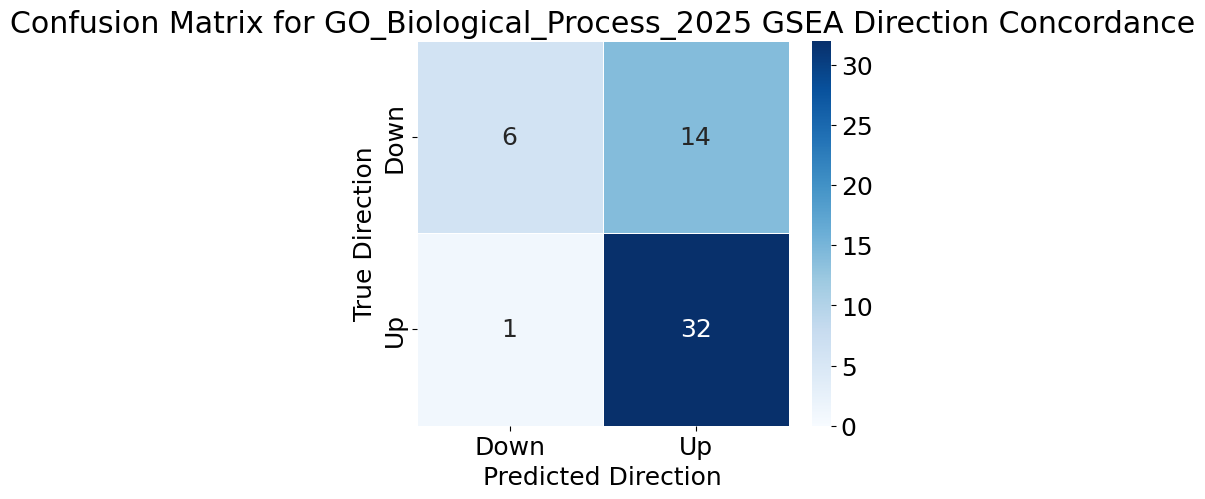

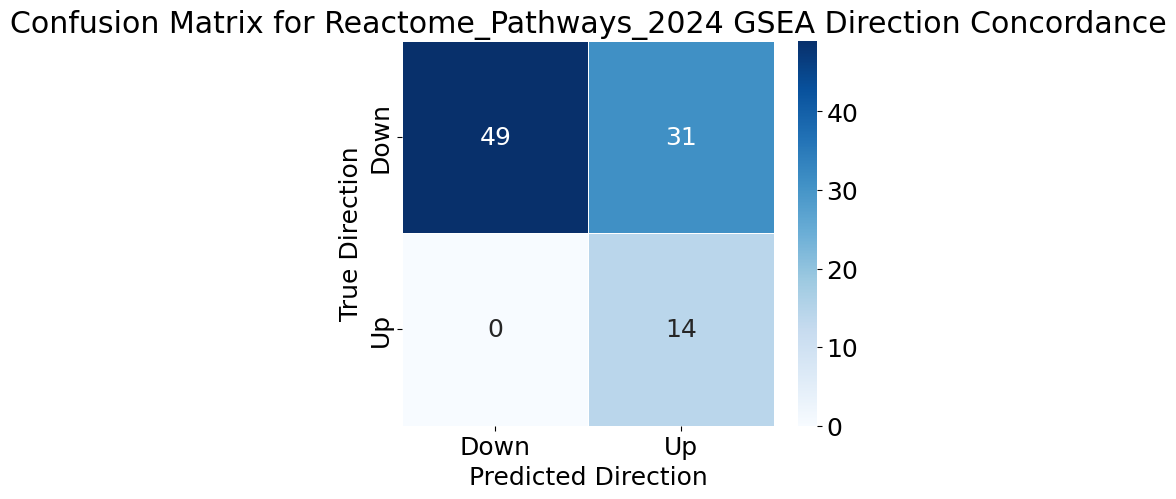

In [52]:
# plot confusion matrix for observed vs real based on direction concordance without any permutation
from sklearn.metrics import confusion_matrix
for name in gsea_disease:
    real_df = gsea_disease[name]
    pred_df = gsea_pred_obs[name]

    # define S from real only
    S = real_df[real_df["FDR q-val"] < 0.05].copy()
    S = S[S["NES"].abs() >= 1.0]

    merged = S[["Term", "NES"]].merge(
        pred_df[["Term", "NES"]],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )


    y_true = np.sign(merged["NES_real"].to_numpy())
    y_pred = np.sign(merged["NES_pred"].to_numpy())
    # convert to int
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True, fmt='d',
        cmap='Blues',
        vmin=0, vmax=cm.max(),
        linewidths=0.5, linecolor='white',
        cbar=True,
        xticklabels=['Down', 'Up'],
        yticklabels=['Down', 'Up'],
    )
    plt.xlabel('Predicted Direction')
    plt.ylabel('True Direction')
    plt.title(f'Confusion Matrix for {name} GSEA Direction Concordance')
    # save figure
    plt.savefig(os.path.join(res_dir, f'{date}_etv6_pathway_conf_matrix_dir_concordance_{name.replace(" ", "_")}.pdf'),
                bbox_inches='tight')

In [53]:
def permute_gene_labels(rnk, rng):
    # works for DataFrame with first col gene, second col score OR Series with index genes
    if isinstance(rnk, pd.DataFrame):
        genes = rnk.index.to_numpy().flatten()
        scores = rnk['scores'].to_numpy()
        return pd.DataFrame({'scores': scores}, index=rng.permutation(genes))
        # scores = rnk.to_numpy()
        # return pd.Series(scores, index=rng.permutation(genes))

    else:
        raise TypeError("rnk must be a pandas Series or DataFrame")

In [54]:
def permutation_test_for_library(real_ranks, name, gene_set, B=1000, pred_perm=100, seed=123, threads=3):
    rng = np.random.default_rng(seed)

    real_df = gsea_disease[name]
    pred_obs_df = gsea_pred_obs[name]
    T_obs, n_used = direction_concordance(real_df, pred_obs_df, fdr=0.05, min_abs_nes_real=1.0)
    if np.isnan(T_obs) or n_used == 0:
        return None

    T_null = np.empty(B, dtype=float)
    used_terms = set(
        real_df[real_df["FDR q-val"] < 0.05]
        .loc[real_df["NES"].abs() >= 1.0, "Term"]
        .to_numpy()
    )
    gene_set_subset = {
        term: genes
        for term, genes in gene_set.items()
        if term in used_terms
    }
    for b in tqdm(range(B)):
        rnk_perm = permute_gene_labels(real_ranks, rng)
        pred_perm_df = run_prerank(rnk_perm, gene_set_subset, perm=pred_perm, seed=int(rng.integers(1e9)), threads=threads)
        T_b, _ = direction_concordance(real_df, pred_perm_df, fdr=0.05, min_abs_nes_real=1.0)
        T_null[b] = T_b

    p = (1 + np.sum(T_null >= T_obs)) / (B + 1)
    return {
        "T_obs": T_obs,
        "n_used": n_used,
        "p_emp": p,
        "null_mean": float(T_null.mean()),
        "null_sd": float(T_null.std(ddof=1)),
        "z": float((T_obs - T_null.mean()) / T_null.std(ddof=1)),
        "T_null": T_null,
    }
perm_results = {}

for gene_set, name in LIBS:

    perm_results[name] = permutation_test_for_library(etv6_pert_ranks_df, name, gene_set, B=5000, pred_perm=10, seed=0, threads=4)
    r = perm_results[name]
    print(name, "p_emp:", r["p_emp"], "T_obs:", r["T_obs"], "null_mean:", r["null_mean"])

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [08:44<00:00,  9.54it/s]


GO_Biological_Process_2025 p_emp: 0.17356528694261147 T_obs: 0.6348484848484849 null_mean: 0.49970060606060607


100%|██████████| 5000/5000 [13:19<00:00,  6.25it/s]

Reactome_Pathways_2024 p_emp: 0.01279744051189762 T_obs: 0.80625 null_mean: 0.49876624999999997


In [226]:
# save perm_results as pkl file
import pickle
with open(os.path.join(res_dir, f'{date}_etv6_pathway_permutation_results.pkl'), 'wb') as f:
    pickle.dump(perm_results, f)

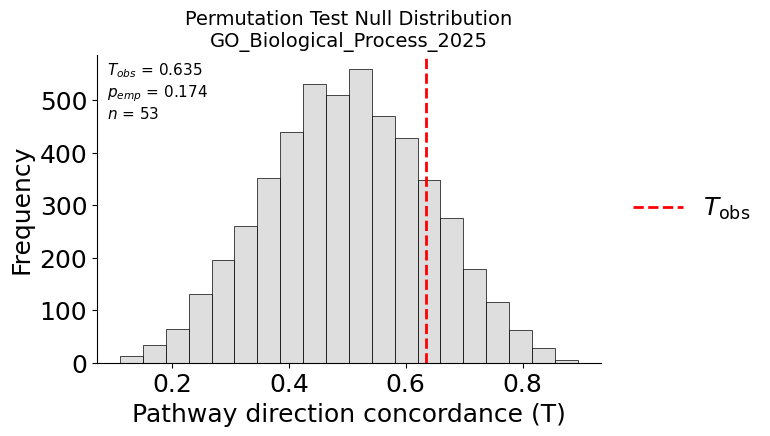

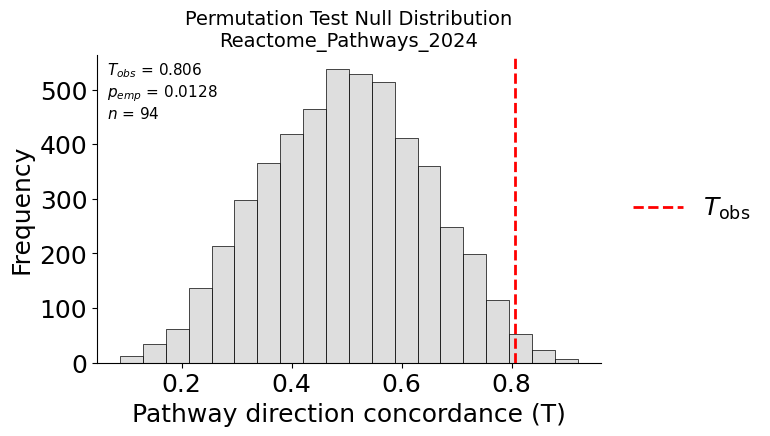

In [ ]:
for name in perm_results:
    r = perm_results[name]
    T_null = r["T_null"]
    T_obs = r["T_obs"]

    plt.figure(figsize=(6.5, 4))

    sns.histplot(
        T_null,
        bins=20,
        color="lightgray",
        edgecolor="black",
        linewidth=0.5
    )

    # observed line
    plt.axvline(
        T_obs,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$T_{\mathrm{obs}}$"
    )

    plt.title(f"Permutation Test Null Distribution\n{name}", fontsize=14)
    plt.xlabel("Pathway direction concordance (T)")
    plt.ylabel("Frequency")

    # annotation box in axes coordinates (clean + stable)
    txt = (
        f"$T_{{obs}}$ = {T_obs:.3f}\n"
        f"$p_{{emp}}$ = {r['p_emp']:.3g}\n"
        f"$n$ = {r['n_used']}"
    )

    plt.text(
        0.02, 0.98,
        txt,
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

    # legend outside the plot
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # save figure
    plt.savefig(
        os.path.join(res_dir, f"{date}_etv6_pathway_histplot_dir_concordance_{name.replace(' ', '_')}.pdf"),
        dpi=300,
        bbox_inches="tight"
    )

In [56]:
def plot_permutation_violin(T_null, T_obs, p_emp, n_used, title=None):
    fig, ax = plt.subplots(figsize=(4, 6))

    # Violin for null distribution
    parts = ax.violinplot(
        T_null,
        positions=[0],
        widths=0.6,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for pc in parts['bodies']:
        pc.set_facecolor("lightgray")
        pc.set_edgecolor("black")
        pc.set_alpha(0.8)

    # Null mean
    null_mean = np.mean(T_null)
    ax.hlines(
        null_mean,
        xmin=-0.25,
        xmax=0.25,
        linestyles="dashed",
        colors="black",
        linewidth=1,
        label="Null mean",
    )

    # Observed value
    ax.scatter(
        0,
        T_obs,
        color="#1f77b4",
        s=60,
        zorder=3,
        label="Observed",
    )

    # Formatting
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0])
    ax.set_xticklabels(["Permutation Baseline"])
    ax.set_ylabel("Balanced Accuracy Score", fontsize=14)

    # Annotation
    text = (
        f"$T_{{obs}}$ = {T_obs:.2f}\n"
        f"$p_{{emp}}$ = {p_emp:.4f}\n"
        f"$n$ = {n_used}"
    )
    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none"),
    )
    ax.hlines(
        T_obs,
        xmin=-0.25,
        xmax=0.25,
        linestyles="dotted",
        colors="#1f77b4",
        linewidth=1.5,
    )

    ax.text(
        0.28,
        T_obs,
        "Model prediction",
        va="center",
        ha="left",
        fontsize=9,
        color="#1f77b4",
    )

    if title:
        ax.set_title(title, fontsize=12)

    plt.tight_layout()

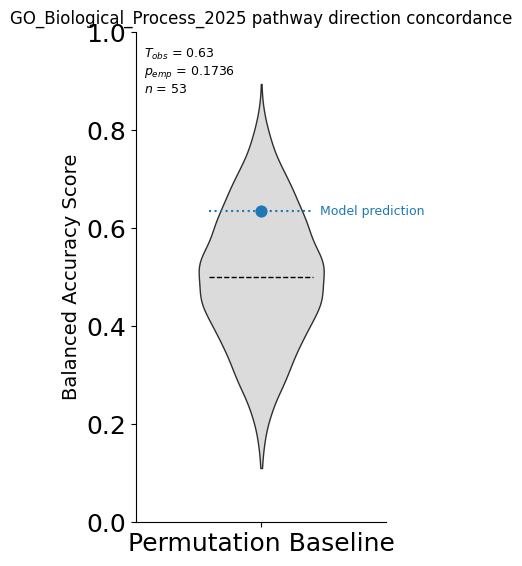

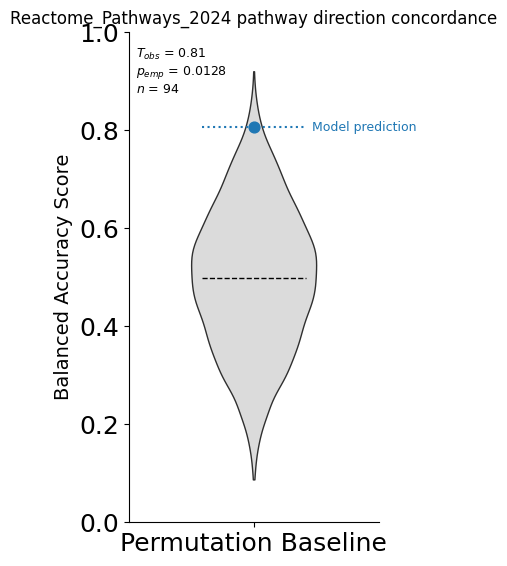

In [ ]:
for name in perm_results:
    r = perm_results[name]
    plot_permutation_violin(
        T_null=r["T_null"],
        T_obs=r["T_obs"],
        p_emp=r["p_emp"],
        n_used=r["n_used"],
        title=f"{name} pathway direction concordance",
    )
    plt.savefig(os.path.join(res_dir, f'{date}_etv6_pathway_violin_dir_concordance_{name.replace(" ", "_")}.pdf'),
                bbox_inches='tight')


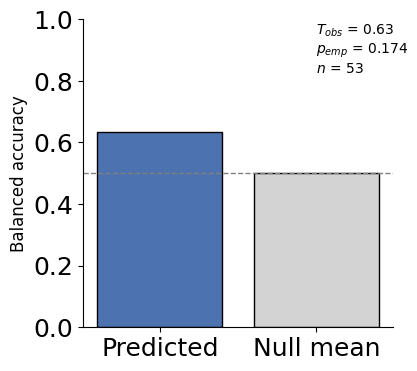

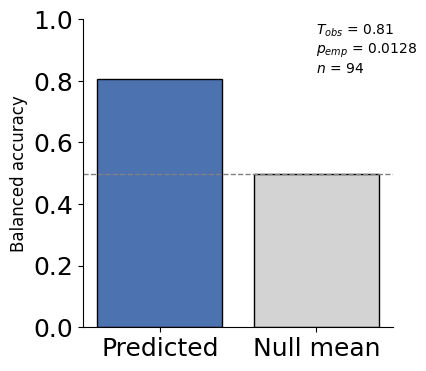

In [58]:
# also plot barplot of observed vs null mean where for null mean also plot std as error bar
for name in perm_results:
    r = perm_results[name]
    T_null = r["T_null"]
    T_obs = r["T_obs"]
    null_mean = r["null_mean"]
    null_sd = r["null_sd"]
    p_emp = r["p_emp"]
    n_used = r['n_used']

    lo, hi = np.percentile(T_null, [2.5, 97.5])
    mu = null_mean

    # asymmetric errors for the null mean bar
    yerr = np.array([[mu - lo], [hi - mu]])

    plt.figure(figsize=(4,4))
    plt.bar(["Predicted", "Null mean"], [T_obs, mu], color=["#4C72B0", "lightgray"], edgecolor="black")

    plt.ylim(0, 1)
    plt.ylabel("Pathway direction concordance (T)")

    # reference line
    plt.axhline(
        null_mean,
        linestyle="--",
        color="gray",
        linewidth=1
    )

    plt.ylabel("Balanced accuracy", fontsize=12)
    plt.ylim(0, 1)

    # annotation
    plt.text(
        0.75, 0.99,
        f"$T_{{obs}}$ = {T_obs:.2f}\n"
        f"$p_{{emp}}$ = {p_emp:.3g}\n"
        f"$n$ = {n_used}",
        transform=plt.gca().transAxes,
        va="top",
        fontsize=10
    )


    # # save figure
    # plt.savefig(
    #     os.path.join(res_dir, f"{date}_etv6_pathway_barplot_dir_concordance_{name.replace(' ', '_')}.pdf"),
    #     dpi=300,
    #     bbox_inches="tight"
    # )


In [77]:
gsea_results = {}
enr_insilico_etv6_results = {}
enr_tf_etv6_results = {}
for gene_set, name in zip([go_bio, reactome_2024, msigdb], ['GO_Biological_Process_2025', 'Reactome_Pathways_2024', 'MSigDB_Hallmark_2020']):
    
    enr_tf_etv6 = gp.prerank(
        rnk=etv6_ranks,
        threads=1,
        gene_sets=gene_set,
        min_size=10,
        max_size=500,
        outdir=None,
        permutation_num=5000,  # reduce number to speed up testing
        seed=42,
        verbose=True,
    )
    enr_insilico_etv6 = gp.prerank(
        rnk=etv6_pert_ranks,
        threads=1,
        gene_sets=gene_set,
        min_size=10,
        max_size=500,
        outdir=None,
        permutation_num=5000,  # reduce number to speed up testing
        seed=42,
        verbose=True,
    )
    enr_insilico_etv6_results[name] = enr_insilico_etv6
    enr_tf_etv6_results[name] = enr_tf_etv6
    # pick useful columns; rename for clarity
    cols = ["Term", "NES", "FDR q-val", "Lead_genes"]
    left  = enr_insilico_etv6.res2d[cols].copy().drop_duplicates("Term")
    right = enr_tf_etv6.res2d[cols].copy().drop_duplicates("Term")
    left.columns  = ["Term", "NES_pred", "FDR_insilico", "Lead_genes_pred"]
    right.columns = ["Term", "NES_real",       "FDR_tf",       "Lead_genes_real"]

    # robust inner join on term
    cmp_df = (
        left.merge(right, on="Term", how="inner")
            .dropna(subset=["NES_pred", "NES_real"])
    )

    # optional sanity columns
    cmp_df["sign_consistent"] = (cmp_df["NES_pred"] * cmp_df["NES_real"]) > 0
    cmp_df["abs_delta_NES"]   = (cmp_df["NES_pred"] - cmp_df["NES_real"]).abs()

    float_cols = ["NES_pred", "FDR_insilico", "NES_real", "FDR_tf", "abs_delta_NES"]
    cmp_df[float_cols] = cmp_df[float_cols].astype(float)

    gsea_results[name] = cmp_df

2026-03-27 17:41:43,532 [WARNING] Duplicated values found in preranked stats: 24.99% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-27 17:41:43,561 [INFO] Parsing data files for GSEA.............................
2026-03-27 17:41:43,662 [INFO] 4000 gene_sets have been filtered out when max_size=500 and min_size=10
2026-03-27 17:41:43,669 [INFO] 1341 gene_sets used for further statistical testing.....
2026-03-27 17:41:43,670 [INFO] Start to run GSEA...Might take a while..................
2026-03-27 17:44:27,131 [INFO] Congratulations. GSEApy runs successfully................

2026-03-27 17:44:27,152 [WARNING] Duplicated values found in preranked stats: 5.81% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-27 17:44:27,154 [INFO] Parsing data files for GSEA.............................
2026-03-27 17:44:27,182 [INFO] 4000 gene_sets have been filtered out when max_size=500 and min_size=10
2

In [227]:
# save GSEA results
gsea_res_dir = Path(res_dir) / 'gsea_results'
gsea_res_dir.mkdir(parents=True, exist_ok=True)
for name, df in gsea_disease.items():
    # as csv
    df.to_csv(gsea_res_dir / f'{date}_gsea_real_{name}_ETV6.csv', index=False)

In [ ]:
# merge gsea_real_filtered and gsea_pred_obs into gsea_results_filtered with suffixes _real and _pred
gsea_merged_filtered = {}
for name in gsea_disease:
    gsea_merged_filtered[name] = gsea_results_filtered[name].merge(
        gsea_pred_obs[name],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )
    # save as csv
    gsea_merged_filtered[name].to_csv(gsea_res_dir / f'{date}_gsea_merged_filtered_{name}_ETV6.csv', index=False)

In [229]:
from matplotlib.lines import Line2D

import numpy as np, matplotlib.pyplot as plt

# def plot_cmp(df, name):
def plot_cmp(df, name):
    same = df["sign_consistent"].astype(bool).values
    colors = np.where(same, "#4C72B0", "#CC3311")  # blue for tp/tn (same sign), red for the rest

    plt.figure(figsize=(6, 6))
    plt.scatter(df["NES_pred"], df["NES_real"], s=18, alpha=0.8, c=colors)
    plt.axhline(0, ls="--", lw=1, c="grey")
    plt.axvline(0, ls="--", lw=1, c="grey")

    # compute chi-square test
    chi2, p = chi2_contingency(pd.crosstab(df["NES_real"]>0, df["NES_pred"] > 0))[:2]
    print(pd.crosstab(df["NES_real"]>0, df["NES_pred"] > 0))
    print(f'Chi-square: {chi2}, p-val: {p}')
    plt.text(
        0.95,
        0.15,
        f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )


    plt.xlabel("insilico NES")
    plt.ylabel("TF NES")

    blue_patch = Line2D([0], [0], marker='o', color='w',
                        markerfacecolor="#4C72B0", markersize=8,
                        label=f"same sign n={int(same.sum())}",
                        )
    red_patch = Line2D([0], [0], marker='o', color='w',
                       markerfacecolor="#CC3311", markersize=8,
                       label=f"flip n={int((~same).sum())}")
    # plot legend outside of the plot
    plt.legend(handles=[blue_patch, red_patch], loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

    plt.savefig(f"{res_dir}/etv6_gsea_FDR0.05_{name}.pdf", dpi=300, bbox_inches="tight")
    plt.close()

In [230]:
gsea_merged_filtered

{'GO_Biological_Process_2025':                                                  Term  NES_real  \
 0   Antigen Processing and Presentation of Exogeno...  2.314345   
 1   Positive Regulation of Immune Response (GO:005...  2.308482   
 2   Positive Regulation of Leukocyte Mediated Cyto...  2.273892   
 3          Regulation of Immune Response (GO:0050776)  2.204936   
 4   Positive Regulation of Immune System Process (...  2.197886   
 5   Antigen Processing and Presentation of Peptide...  2.177559   
 6   Antigen Processing and Presentation of Exogeno...  2.177559   
 7   Regulation of T Cell Mediated Cytotoxicity (GO...  2.176388   
 8   Positive Regulation of T Cell Activation (GO:0...  2.113491   
 9   Positive Regulation of Lymphocyte Activation (...   2.05925   
 10  Positive Regulation of T Cell Mediated Cytotox...  2.051168   
 11  Positive Regulation of T Cell Mediated Immunit...  2.021897   
 12       Regulation of T Cell Activation (GO:0050863)   2.01106   
 13    Regulation 

In [231]:
# load the results here if already saved
gsea_results = {}
gsea_results_filtered = {}
for name in ['GO_Biological_Process_2025', 'Reactome_Pathways_2024']:
    gsea_results[name] = pd.read_csv(gsea_res_dir / f'{date}_gsea_merged_filtered_{name}_ETV6.csv')
    # filter for significant pathways in FDR_tf < 0.25
    gsea_merged_filtered[name]['sign_consistent'] = (gsea_merged_filtered[name]['NES_pred'] * gsea_merged_filtered[name]['NES_real']) > 0
    plot_cmp(gsea_merged_filtered[name], name)

NES_pred  False  True 
NES_real              
False         6     14
True          1     32
Chi-square: 5.724022444946359, p-val: 0.01673435026166026
NES_pred  False  True 
NES_real              
False        49     31
True          0     14
Chi-square: 15.541858600583094, p-val: 8.06984210236053e-05


In [66]:
def build_sigma_from_full_sets(pathway_genes: dict,
                               universe_genes: set,
                               lam: float = 0.3,
                               min_size: int = 15,
                               max_size: int = 500,
                               variances: dict | None = None):
    """
    pathway_genes: dict {pathway_id: iterable_of_genes} using FULL membership
    universe_genes: set of genes eligible in both analyses
    lam: shrinkage toward identity
    variances: optional dict {pathway_id: variance_of_null_NES}; if None, unit variances

    Returns:
      ids (list), Sigma (ndarray)
    """
    # 1) restrict to universe, apply size filter
    cleaned = {}
    for pid, genes in pathway_genes.items():
        g = set(map(str, genes)) & universe_genes
        if min_size <= len(g) <= max_size:
            cleaned[pid] = g
    ids = sorted(cleaned.keys())
    m = len(ids)


    # 2) cosine similarity matrix
    sizes = np.array([len(cleaned[i]) for i in ids], float)
    S = np.eye(m)
    for i in range(m):
        Ai = cleaned[ids[i]]
        for j in range(i+1, m):
            Aj = cleaned[ids[j]]
            inter = len(Ai & Aj)
            den = (sizes[i]*sizes[j])**0.5 if sizes[i] and sizes[j] else 0.0
            S[i,j] = S[j,i] = (inter/den) if den>0 else 0.0

    # 3) shrinkage to ensure positive definiteness / stability
    R = (1 - lam) * S + lam * np.eye(m)

    # 4) (optional) scale by per-pathway variances
    if variances is None:
        Sigma = R
    else:
        d = np.array([max(variances.get(pid, 1.0), 1e-12) for pid in ids], float)
        Dhalf = np.sqrt(d)
        Sigma = (R * Dhalf).T * Dhalf

    # 5) tiny eigen clip as a safeguard
    w, V = np.linalg.eigh(Sigma)
    w = np.clip(w, 1e-8, None)
    Sigma = (V * w) @ V.T
    return ids, Sigma, S

In [61]:
concat_gsea_res = pd.concat(
    [gsea_merged_filtered['GO_Biological_Process_2025'],
     gsea_merged_filtered['Reactome_Pathways_2024'],
     ]
)

In [62]:
# add column to count number of leading edge genes
concat_gsea_res['n_leading_genes_pred'] = concat_gsea_res['Lead_genes_pred'].apply(
    lambda x: len(x.split(';')) if isinstance(x, str) else 0
)
concat_gsea_res['n_leading_genes_real'] = concat_gsea_res['Lead_genes_real'].apply(
    lambda x: len(x.split(';')) if isinstance(x, str) else 0
)
# check if signs of NES are consistent
concat_gsea_res['directionality'] = (np.sign(concat_gsea_res['NES_pred']) == np.sign(concat_gsea_res['NES_real']))

In [ ]:
# # filter for minimum number of leading edge genes
# concat_gsea_res = concat_gsea_res[
#     (concat_gsea_res['n_leading_geNES_real'] >= 3)
# ]

In [67]:
# concatenate GO and reactome first
combined_pathways = {**go_bio, **reactome_2024}
# filter for significant pathways in concat_gsea_res
combined_pathways = {
    row['Term']: combined_pathways[row['Term']]
    for _, row in concat_gsea_res.iterrows()
    if row['Term'] in combined_pathways
}
universe_genes = set(etv6_ranks.index) & set(etv6_pert_ranks.index)
print(f'Number of universe genes: {len(universe_genes)}')
print(f'Number of pathways: {len(combined_pathways)}')
ids, Sigma, S = build_sigma_from_full_sets(
    combined_pathways, 
    universe_genes,
)

Number of universe genes: 4890
Number of pathways: 147


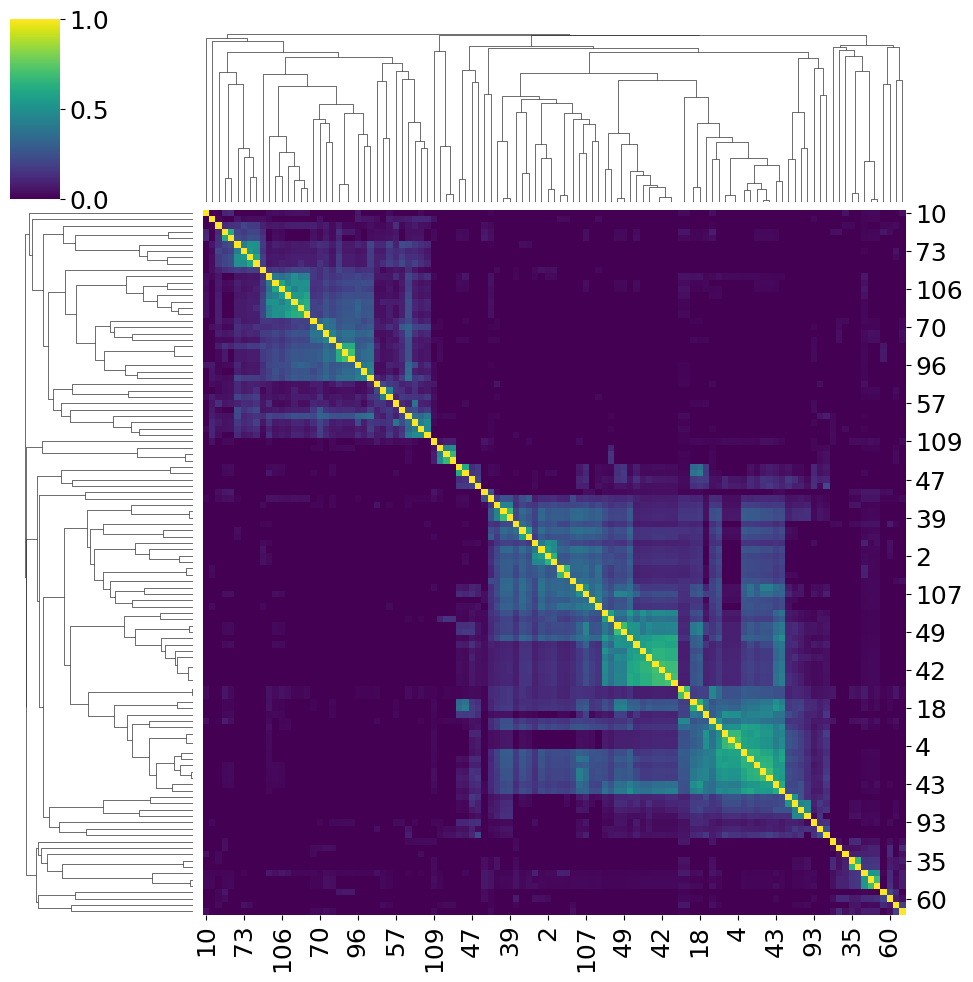

In [296]:
# create a clustermap based on sigma
dist = 1 - S
Z = linkage(squareform(dist), method="average")

clusters = fcluster(Z, t=0.6, criterion="distance")

cluster_map = pd.DataFrame({"Term": ids, "cluster": clusters})
# # print cluster number
# cluster_map['cluster'].value_counts().head(20)
sns.clustermap(Sigma, row_linkage=Z, col_linkage=Z, cmap="viridis")
# save figure
plt.savefig(res_dir + f'{date}_gsea_pathway_correlation_clustermap_ETV6.pdf', dpi=300)

In [297]:
# Align your dataframe to 'ids' and fit GLS


df_gls = concat_gsea_res[concat_gsea_res['Term'].isin(ids)].set_index('Term').loc[ids].reset_index()
import statsmodels.api as sm
X = sm.add_constant(df_gls['NES_pred'].astype(float).to_numpy())
y = df_gls['NES_real'].astype(float).to_numpy()
res = sm.GLS(y, X, sigma=Sigma).fit()
print(res.summary())

                            GLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.165
Model:                            GLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     21.54
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           9.69e-06
Time:                        14:09:12   Log-Likelihood:                -101.36
No. Observations:                 111   AIC:                             206.7
Df Residuals:                     109   BIC:                             212.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6246      0.145     -4.317      0.0

#### Fig 5h, GSEA comparison between in silico and monogenic ETV6 mutation

Index([26.0, 24.0, 23.0, 5.0, 4.0, 2.0, 9.0, 27.0, 21.0, 22.0, 32.0, 14.0], dtype='float64', name='cluster')
NES_pred  False  True 
NES_real              
False        55     45
True          1     46
Chi-square: 35.69148271276596, p-val: 2.311725030275692e-09


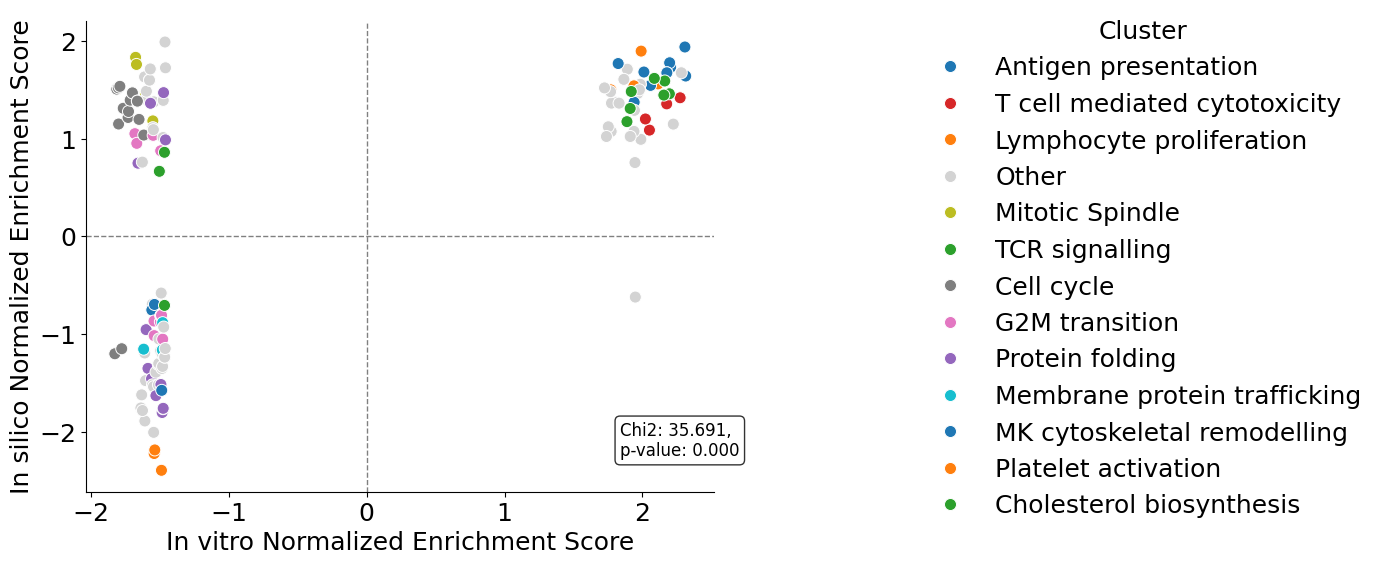

In [322]:
# sort by cluster
# concat_gsea_res
plt.figure(figsize=(16,6))
# add cluster info to concat_gsea_res
term_to_cluster = {term: cluster for term, cluster in zip(cluster_map['Term'], cluster_map['cluster'])}
concat_gsea_res['cluster'] = concat_gsea_res['Term'].map(term_to_cluster)
# only keep clusters with more than 5 members
cluster_counts = concat_gsea_res['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts >= 3].index
print(valid_clusters)
concat_gsea_res['plot_cluster'] = concat_gsea_res['cluster'].where(concat_gsea_res['cluster'].isin(valid_clusters), other='Other')
# # map cluster numbers to strings for better legend
cluster_naming = {
    '5.0': 'Antigen presentation',
    '9.0': 'Lymphocyte proliferation',
    '4.0': 'TCR signalling',
    '2.0': 'T cell mediated cytotoxicity',
    '23.0': 'Protein folding',
    '36.0': 'Megakaryocyte development',
    '24.0': 'G2M transition',
    '26.0': 'Cell cycle',
    '27.0': 'Mitotic Spindle',
    '22.0': 'Membrane protein trafficking',
    '21.0': 'MK cytoskeletal remodelling',
    '32.0': 'Platelet activation',
    '14.0': 'Cholesterol biosynthesis',

}
# create cmap to set 'Other' to gray
cmap = sns.color_palette("tab10", n_colors=len(cluster_naming))
cmap_dict = {name: cmap[i] for i, name in enumerate(cluster_naming.values())}
cmap_dict['Other'] = 'lightgray'
# map clusters
concat_gsea_res['plot_cluster'] = concat_gsea_res['plot_cluster'].astype(str).map(
    lambda x: cluster_naming.get(x, x)
)
sns.scatterplot(
    data=concat_gsea_res, x="NES_real", y="NES_pred",
    hue="plot_cluster", s=75,
    palette=cmap_dict
)
# sns.regplot(data=concat_gsea_res, x="NES_pred", y="NES_real",
#             scatter=False, color="black", line_kws={"lw":2})
# plot legend outside
plt.legend(bbox_to_anchor=(1.3, 1.05), loc='upper left', title='Cluster')
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
# plt.title("Alignment of NES across datasets")
plt.tight_layout()
plt.ylabel("In silico Normalized Enrichment Score")
plt.xlabel("In vitro Normalized Enrichment Score")

# counts correctly and incorrectly predicted directions
n_correct = np.sum(
    (concat_gsea_res['NES_pred'] * concat_gsea_res['NES_real']) > 0
)
n_incorrect = np.sum(
    (concat_gsea_res['NES_pred'] * concat_gsea_res['NES_real']) < 0
)
# compute chi-square test
chi2, p = chi2_contingency(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))[:2]
print(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))
print(f'Chi-square: {chi2}, p-val: {p}')
plt.text(
    0.85,
    0.15,
    f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
# savefig
plt.savefig(res_dir + f'{date}_gsea_FDR0.05_NES_comparison_ETV6.pdf', dpi=300)

In [309]:
concat_gsea_res.plot_cluster.unique()

array(['Antigen presentation', 'T cell mediated cytotoxicity',
       'Lymphocyte proliferation', 'Other', 'Mitotic Spindle',
       'TCR signalling', 'Cell cycle', 'G2M transition',
       'Protein folding', '22.0', '21.0', '32.0', '14.0'], dtype=object)

NES_pred  False  True 
NES_real              
False        55     45
True          1     46
Chi-square: 35.69148271276596, p-val: 2.311725030275692e-09


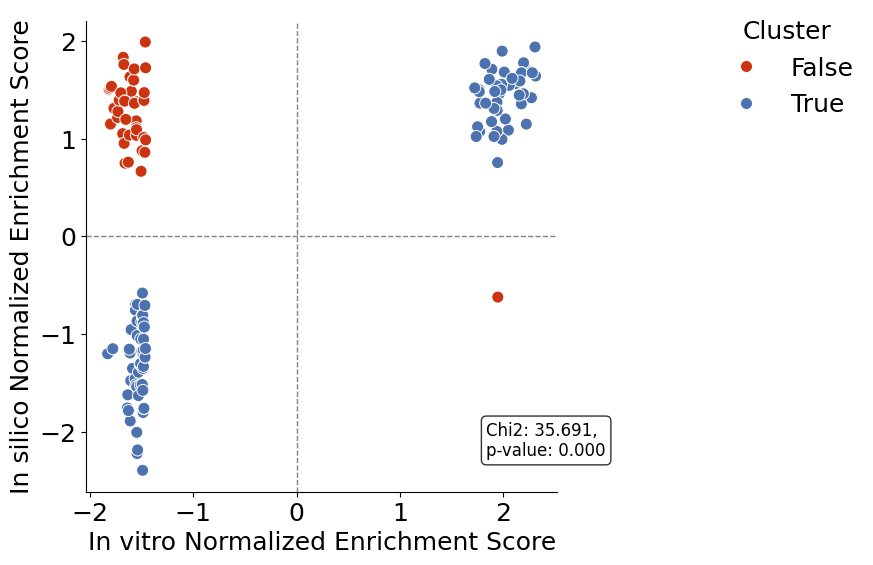

In [329]:
# sort by cluster
# concat_gsea_res
plt.figure(figsize=(10,6))
concat_gsea_res["sign_consistent"] = (concat_gsea_res['NES_pred'] * concat_gsea_res['NES_real']) > 0
same = concat_gsea_res["sign_consistent"].astype(bool).values


sns.scatterplot(
    data=concat_gsea_res, x="NES_real", y="NES_pred",s=75,
    hue="sign_consistent", palette={True: "#4C72B0", False: "#CC3311"}
)
# sns.regplot(data=concat_gsea_res, x="NES_pred", y="NES_real",
#             scatter=False, color="black", line_kws={"lw":2})
# plot legend outside
plt.legend(bbox_to_anchor=(1.3, 1.05), loc='upper left', title='Cluster')
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
# plt.title("Alignment of NES across datasets")
plt.tight_layout()
plt.ylabel("In silico Normalized Enrichment Score")
plt.xlabel("In vitro Normalized Enrichment Score")

# counts correctly and incorrectly predicted directions
n_correct = np.sum(
    (concat_gsea_res['NES_pred'] * concat_gsea_res['NES_real']) > 0
)
n_incorrect = np.sum(
    (concat_gsea_res['NES_pred'] * concat_gsea_res['NES_real']) < 0
)
# compute chi-square test
chi2, p = chi2_contingency(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))[:2]
print(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))
print(f'Chi-square: {chi2}, p-val: {p}')
plt.text(
    0.85,
    0.15,
    f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
# savefig
plt.savefig(res_dir + f'{date}_gsea_FDR0.05_NES_comparison_sign.pdf', dpi=300)

In [ ]:


stats = {}
# for name, df in concat_gsea_res.items():
# use both as numerical values
concat_gsea_res['NES_pred'] = concat_gsea_res['NES_pred'].astype(float)
concat_gsea_res['NES_real'] = concat_gsea_res['NES_real'].astype(float)
sp = spearmanr(concat_gsea_res["NES_pred"], concat_gsea_res["NES_real"]).statistic
pe = pearsonr(concat_gsea_res["NES_pred"], concat_gsea_res["NES_real"]).statistic
stats = {
    "n_terms": len(concat_gsea_res),
    "spearman": sp,
    "pearson": pe,
    "same_sign_frac": concat_gsea_res["sign_consistent"].mean(),
}


In [78]:
platelet_df = concat_gsea_res[concat_gsea_res['Term'].isin(['Platelet Aggregation (GO:0070527)'])]
# lead genes for this term from both analyses
all_lead_genes = []
for name, df in gsea_results.items():
    if name != 'GO_Biological_Process_2025':
        continue
    le_genes = df[df['Term'] == 'Platelet Aggregation (GO:0070527)']['Lead_genes_real']
    if not le_genes.empty:
        genes = le_genes.values[0].split(';')
        all_lead_genes.extend(genes)
    # le_genes = df[df['Term'] == 'Platelet Aggregation (GO:0070527)']['Lead_genes_insilico']
    # if not le_genes.empty:
    #     genes = le_genes.values[0].split(';')
    #     all_lead_genes.extend(genes)
all_lead_genes = list(set(all_lead_genes))

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

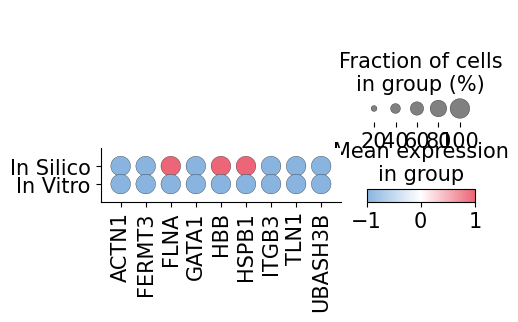

In [79]:
# subset the deg tables
in_silico_ranks_ = degs_pert[degs_pert['names'].isin(all_lead_genes)]
etv6_ko_ranks_ = degs_etv6[degs_etv6['names'].isin(all_lead_genes)]

# align on the same gene order (use gata1 order)
etv6_ko_ranks_ = etv6_ko_ranks_[etv6_ko_ranks_['names'].isin(in_silico_ranks_['names'])]
order = in_silico_ranks_['names'].tolist()

tf_aligned   = (etv6_ko_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())
in_silico_aligned = (in_silico_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())


merged_aligned = tf_aligned.merge(in_silico_aligned, on="names", suffixes=("_etv6", "_insilico"))
# sort by logFC_tf (largest first)
merged_aligned = merged_aligned.sort_values("logfoldchanges_etv6", ascending=False)

X = np.concatenate([
    merged_aligned['logfoldchanges_etv6'].values[:, None],
    merged_aligned['logfoldchanges_insilico'].values[:, None],
], axis=1)
adata_genes = sc.AnnData(X=X.T)
adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})

adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})


# replace X so that it is 1 for positive logFC and -1 for negative logFC
adata_genes.X = np.where(adata_genes.X > 0, 1, -1)
# define extreme colors: negative -> red, zero -> white, positive -> blue
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "posneg_extremes", ["#8ab4e0", "#FFFFFF", "#ed6677"]
)
norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

sc.pl.dotplot(
    adata_genes,
    var_names=sorted(adata_genes.var_names),
    groupby='method',
    swap_axes=False,
    cmap=cmap,
    # norm=norm,
    vmin=-1, vmax=1,
    mean_only_expressed=False,
    expression_cutoff=-np.inf,
    show=False,
    # figsize=(2.35, 10)
)
# # save figure
# plt.savefig(f"{res_dir}/ETV6_platelet_aggregation_leading_edge_genes_dotplot.pdf", dpi=300, bbox_inches="tight")

In [80]:
cell_junction_df = concat_gsea_res[concat_gsea_res['Term'].isin(['Cell-Cell Junction Organization (GO:0045216)'])]
# lead genes for this term from both analyses
all_lead_genes = []
for name, df in gsea_results.items():
    print(df)
    le_genes = df[df['Term'] == 'Cell-Cell Junction Organization (GO:0045216)']['Lead_genes_real']
    if not le_genes.empty:
        genes = le_genes.values[0].split(';')
        all_lead_genes.extend(genes)
    # le_genes = df[df['Term'] == 'Non-integrin membrane-ECM interactions']['Lead_geNES_pred']
    # if not le_genes.empty:
    #     genes = le_genes.values[0].split(';')
    #     all_lead_genes.extend(genes)
all_lead_genes = list(set(all_lead_genes))

                                                   Term  NES_pred  \
0                     Platelet Aggregation (GO:0070527) -1.871470   
1                          Eye Development (GO:0001654) -1.843021   
2             Homotypic Cell-Cell Adhesion (GO:0034109) -1.832496   
3        Myeloid Leukocyte Differentiation (GO:0002573)  1.796524   
4       Regulation of B Cell Proliferation (GO:0030888)  1.787467   
...                                                 ...       ...   
1336            Mesenchymal Cell Migration (GO:0090497) -0.501721   
1337             Steroid Metabolic Process (GO:0008202)  0.492991   
1338  Anterior/Posterior Pattern Specification (GO:0... -0.491990   
1339                     Protein Secretion (GO:0009306) -0.448474   
1340  Positive Regulation of Nuclear Division (GO:00...  0.433532   

      FDR_insilico                                    Lead_genes_pred  \
0         0.070408        FERMT3;ITGB3;PLEK;VCL;GATA1;ACTN1;TLN1;MYL9   
1         0.068322  PBX1;

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

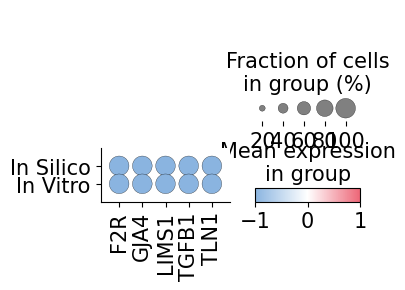

In [81]:
# subset the deg tables
in_silico_ranks_ = degs_pert[degs_pert['names'].isin(all_lead_genes)]
etv6_ko_ranks_ = degs_etv6[degs_etv6['names'].isin(all_lead_genes)]

# align on the same gene order (use gata1 order)
etv6_ko_ranks_ = etv6_ko_ranks_[etv6_ko_ranks_['names'].isin(in_silico_ranks_['names'])]
order = in_silico_ranks_['names'].tolist()

tf_aligned   = (etv6_ko_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())
in_silico_aligned = (in_silico_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())


merged_aligned = tf_aligned.merge(in_silico_aligned, on="names", suffixes=("_etv6", "_insilico"))
# sort by logFC_tf (largest first)
merged_aligned = merged_aligned.sort_values("logfoldchanges_etv6", ascending=False)

X = np.concatenate([
    merged_aligned['logfoldchanges_etv6'].values[:, None],
    merged_aligned['logfoldchanges_insilico'].values[:, None],
], axis=1)
adata_genes = sc.AnnData(X=X.T)
adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})

adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})


# replace X so that it is 1 for positive logFC and -1 for negative logFC
adata_genes.X = np.where(adata_genes.X > 0, 1, -1)
# define extreme colors: negative -> red, zero -> white, positive -> blue
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "posneg_extremes", ["#8ab4e0", "#FFFFFF", "#ed6677"]
)
norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

sc.pl.dotplot(
    adata_genes,
    var_names=sorted(adata_genes.var_names),
    groupby='method',
    swap_axes=False,
    cmap=cmap,
    # norm=norm,
    vmin=-1, vmax=1,
    mean_only_expressed=False,
    expression_cutoff=-np.inf,
    show=False,
    # figsize=(2.35, 10)
)
# # save figure
# plt.savefig(f"{res_dir}/ETV6_cell_cell_junction_organization_leading_edge_genes_dotplot.pdf", dpi=300, bbox_inches="tight")

In [82]:
platelet_df = concat_gsea_res[concat_gsea_res['Term'].isin(['Cell Cycle, Mitotic'])]
# lead genes for this term from both analyses
all_lead_genes = []
for name, df in gsea_results.items():
    le_genes = df[df['Term'] == 'Cell Cycle, Mitotic']['Lead_genes_real']
    if not le_genes.empty:
        genes = le_genes.values[0].split(';')
        all_lead_genes.extend(genes)
    # le_genes = df[df['Term'] == 'Cell Cycle, Mitotic']['Lead_geNES_pred']
    # if not le_genes.empty:
    #     genes = le_genes.values[0].split(';')
    #     all_lead_genes.extend(genes)
all_lead_genes = list(set(all_lead_genes))

In [84]:

antigen_df = concat_gsea_res[concat_gsea_res['Term'].isin(['Antigen Processing and Presentation of Peptide Antigen via MHC Class II (GO:0002495)'])]
# lead genes for this term from both analyses
all_lead_genes = []
for name, df in gsea_results.items():
    le_genes = df[df['Term'] == 'Antigen Processing and Presentation of Exogenous Peptide Antigen via MHC Class II (GO:0019886)']['Lead_genes_real']
    if not le_genes.empty:
        genes = le_genes.values[0].split(';')
        all_lead_genes.extend(genes)
    # le_genes = df[df['Term'] == 'Antigen Processing and Presentation of Peptide Antigen via MHC Class II (GO:0002495)']['Lead_geNES_pred']
    # if not le_genes.empty:
    #     genes = le_genes.values[0].split(';')
    #     all_lead_genes.extend(genes)
all_lead_genes = list(set(all_lead_genes))

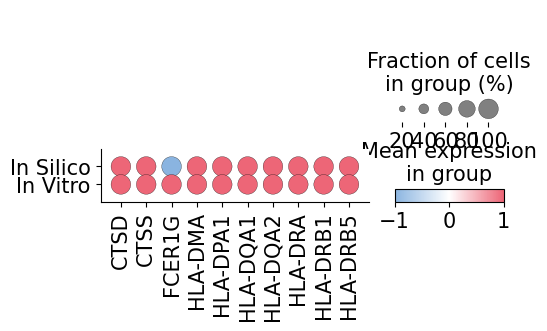

In [85]:
# subset the deg tables
in_silico_ranks_ = degs_pert[degs_pert['names'].isin(all_lead_genes)]
etv6_ko_ranks_ = degs_etv6[degs_etv6['names'].isin(all_lead_genes)]

# align on the same gene order (use gata1 order)
etv6_ko_ranks_ = etv6_ko_ranks_[etv6_ko_ranks_['names'].isin(in_silico_ranks_['names'])]
order = in_silico_ranks_['names'].tolist()

tf_aligned   = (etv6_ko_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())
in_silico_aligned = (in_silico_ranks_.drop_duplicates('names')
                .set_index('names').reindex(order).dropna().reset_index())


merged_aligned = tf_aligned.merge(in_silico_aligned, on="names", suffixes=("_tf", "_gata1"))
# sort by logFC_tf (largest first)
merged_aligned = merged_aligned.sort_values("logfoldchanges_tf", ascending=False)

X = np.concatenate([
    merged_aligned['logfoldchanges_tf'].values[:, None],
    merged_aligned['logfoldchanges_gata1'].values[:, None],
], axis=1)
adata_genes = sc.AnnData(X=X.T)
adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})

adata_genes.var_names = merged_aligned[['names']].values.flatten()
adata_genes.obs = pd.DataFrame({
    'method': ['In Vitro', 'In Silico']
})


# replace X so that it is 1 for positive logFC and -1 for negative logFC
adata_genes.X = np.where(adata_genes.X > 0, 1, -1)
# define extreme colors: negative -> red, zero -> white, positive -> blue
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "posneg_extremes", ["#8ab4e0", "#FFFFFF", "#ed6677"]
)
norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

sc.pl.dotplot(
    adata_genes,
    var_names=sorted(adata_genes.var_names),
    groupby='method',
    swap_axes=False,
    cmap=cmap,
    # norm=norm,
    vmin=-1, vmax=1,
    mean_only_expressed=False,
    expression_cutoff=-np.inf,
    show=False,
    # figsize=(2.35, 10)
)
# save figure
plt.savefig(f"{res_dir}/ETV6_Antigen_Presentation_MHCII_lead_genes_dotplot.pdf", dpi=300, bbox_inches="tight")